# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: Singe IC extraction with squared Wasserstein Distance - Continous

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats

In [2]:
# Simulating Laplace sources (s1 and s2) of size n=100
n = 100
np.random.seed(42)

# Laplace distributed sources, location=0, scale=1
S1 = np.random.laplace(loc=0.0, scale=1.0, size=n)
S2 = np.random.laplace(loc=0.0, scale=1.0, size=n)

# Stack sources
S = np.vstack([S1, S2])

In [3]:
# generating invertible mixing matrix A
A = np.array([[1, 0.5], [0.4, 1]])

# Mixed signals X
X = A @ S

# Converting to pytorch tensors
S_torch = torch.tensor(S, dtype=torch.float32)
X_torch = torch.tensor(X, dtype=torch.float32)

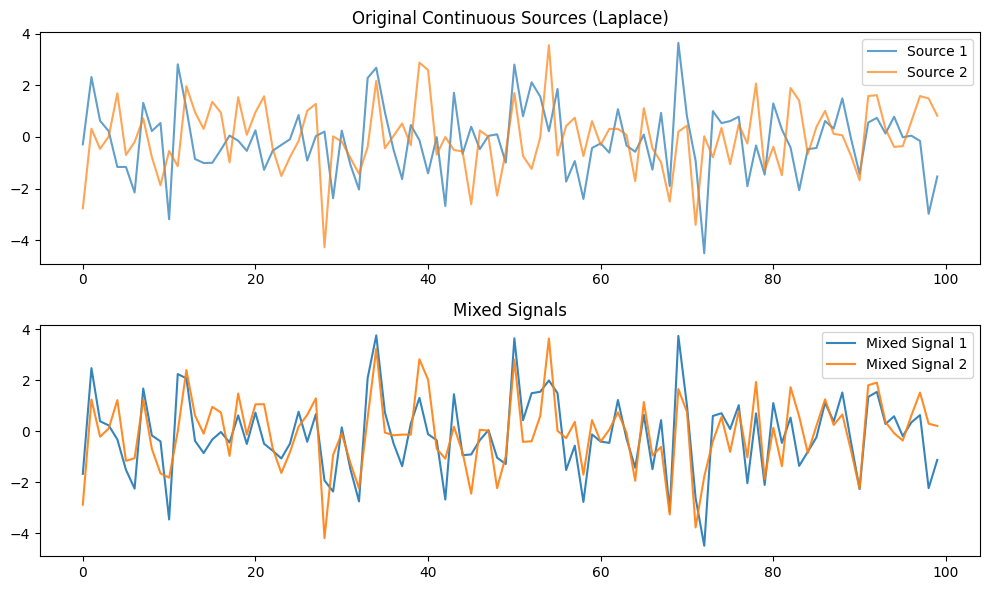

In [4]:
# Plotting sources and mixed signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.title("Original Continuous Sources (Laplace)")
plt.plot(S1, label='Source 1', alpha=0.7)
plt.plot(S2, label='Source 2', alpha=0.7)
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Mixed Signals")
plt.plot(X[0, :], label='Mixed Signal 1', alpha=0.9)
plt.plot(X[1, :], label='Mixed Signal 2', alpha=0.9)
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
class WassersteinICA:
    def __init__(self, X):
        """
        X: torch tensor of mixed signals (shape: num_signals x num_samples)
        """
        self.X = X
        self.n = X.shape[1]
        self.whitened = False
        # constant for numerical stability
        self.epsilon = 1e-7
    
    def whiten(self):
        """
        Whiten the mixture signat, zero mean, unit variance, and uncorrelated.
        """
        # center data
        X_centered = self.X - torch.mean(self.X, dim=1, keepdim=True)
        # compute covariance
        #cov = torch.cov(X_centered)
        cov = torch.matmul(X_centered, X_centered.t()) / (self.n - 1)
        # eigen decomposition
        D, E = torch.linalg.eigh(cov)
        # whitening matrix
        #D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
        D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D))
        W = torch.matmul(D_inv_sqrt, E.T)
        self.X_white = torch.matmul(W, X_centered)
        self.whitened = True
    
    def _empirical_quantile(self, y, q):
        """
        Compute empirical quantile of y at quantile level q using sorting.

        y: 1D torch tensor of shape (num_samples,)
        q: 1D torch tensor of quantile levels in [0, 1] of shape (num_quantiles,)
        returns: quantiles at levels q, shape (num_quantiles,)
        """
        sorted_y, _ = torch.sort(y)
        # quantile position indice
        pos = q * (self.n - 1)
        lower = torch.floor(pos).long()
        upper = torch.ceil(pos).long()
        weight = pos - lower.float()
        quantiles = (1 - weight) * sorted_y[lower] + weight * sorted_y[upper]
        return quantiles
    
    def _normal_quantile(self,q):
        """
        Inverse CDF of standard normal distribution at quantile levels.
        q: torch rensor in [0,1]
        """
        q_np = q.cpu().numpy()
        inv_cdf = scipy.stats.norm.ppf(q_np)
        return torch.tensor(inv_cdf, dtype=torch.float32, device=q.device)
    
    def wasserstein2_distance(self, w):
        """
        Compute the squared wasserstein distance from projections w.X and N(0,1)
        
        w: torch tenrsor of shape (num_signals,), unit norm
        returns: scalar, squared wasserstein distance
        """
        assert self.whitened, "Call whiten() before computing Wasserstein distance."
        # project data
        y = torch.mv(self.X_white.t(), w)
        # quantile levels q
        epsilon = self.epsilon
        q = torch.linspace(epsilon, 1 - epsilon, steps=self.n, device=self.X.device)
        #q = torch.linspace(0, 1, steps=self.n, device=self.X.device)
        F_y_inv = self._empirical_quantile(y, q)
        F_n_inv = self._normal_quantile(q)
        return torch.mean((F_y_inv - F_n_inv) ** 2)

    def wasserstein1_distance(self, w):
        """
        Compute absolute wasserstein distance from projections w.X and N(0,1)
        
        w: torch tenrsor of shape (num_signals,), unit norm
        returns: scalar, absolute wasserstein distance
        """
        assert self.whitened, "Call whiten() before computing Wasserstein distance."
        # project data
        y = torch.mv(self.X_white.t(), w)
        # quantile levels q
        epsilon = self.epsilon
        q = torch.linspace(epsilon, 1 - epsilon, steps=self.n, device=self.X.device)
        F_y_inv = self._empirical_quantile(y, q)
        F_n_inv = self._normal_quantile(q)
        return torch.mean(torch.abs(F_y_inv - F_n_inv))

    def _wasserstein2_gradient_approx(self, w, delta=1e-5):
        grad = torch.zeros_like(w)
        base_val = self.wasserstein2_distance(w)
        for i in range(len(w)):
            w_perturb = w.clone()
            w_perturb[i] += delta
            w_perturb /= torch.norm(w_perturb)
            val = self.wasserstein2_distance(w_perturb)
            grad[i] = (val - base_val) / delta
        return grad


    def optimize_wasserstein2(self, prev_components=None, grid_points=100, continuous=True, max_iter=200, lr=0.1):
        """
        Find one maximizer of squared wasserstein distance over unit sphere,
        optionally orthogonal to previous components.
        
        Parameters:
        prev_components: None or torch tensor of shape (num_prev_components, num_signals)
        grid_points: int, number of discretization points on the sphere
        continous: bool, if True, uses SGD-based optimization, else grid search

        Returns:
        w_best: torch tensor of shape (num_signals,), unit norm
        dist_best: float, corresponding maximal squared wasserstein distance
        """
        if continuous:
            # SGD-based optimization on unit sphere

            # initialize w randomly orthogonal to prev_components if given
            if prev_components is None or prev_components.shape[0] == 0:
                w = torch.randn(self.X.shape[0], device=self.X.device)
            else:
                w = torch.randn(self.X.shape[0], device=self.X.device)
                # orthogonalize w wrt prev_components
                for pc in prev_components:
                    w -= torch.dot(w, pc) * pc
            w = w / torch.norm(w)

            for i in range(max_iter):
                # compute gradient approx (e.g. numeric or analytical; here numeric finite diff)
                grad = self._wasserstein2_gradient_approx(w)
                if prev_components is not None and prev_components.shape[0] > 0:
                    # orthogonalize gradient wrt prev_components to stay feasible
                    for pc in prev_components:
                        grad -= torch.dot(grad, pc) * pc
                
                # Normalize the gradient vector for stable updates
                grad = grad / (torch.norm(grad) + 1e-10)

                # update step
                w = w + lr * grad

                # re-normalize to unit norm
                w = w / torch.norm(w)

            dist = self.wasserstein2_distance(w)
            return w, dist.item()
        else:
            # grid search method for discrete case
            angles = torch.linspace(0, 2 * np.pi, steps=grid_points, device=self.X.device)
            candidates = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)

            if prev_components is not None and prev_components.shape[0] > 0:
                # Orthogonalize candidates w.r.t. previous components
                # using Gram-Schmidt process
                proj = torch.matmul(candidates, prev_components.t())
                candidates = candidates - torch.matmul(proj, prev_components)
                norms = torch.norm(candidates, dim=1, keepdim=True)
                # filter out near zero norms (numerical stability)
                mask = norms.squeeze() > 1e-6
                candidates = candidates[mask]
                if candidates.shape[0] == 0:
                    raise ValueError("No valid candidates after orthogonalization.")
                candidates = candidates / norms[mask]
            
            dist_best = -np.inf
            w_best = None
            for w in candidates:
                dist = self.wasserstein2_distance(w)
                dist_val = dist.item()
                if dist_val > dist_best:
                    dist_best = dist_val
                    w_best = w
            
            return w_best, dist_best

In [6]:
ica = WassersteinICA(X_torch)
ica.whiten()

cov_white = torch.matmul(ica.X_white, ica.X_white.t()) / (ica.n - 1)
print("Whitened covariance:\n", cov_white.numpy())

w1, dist1 = ica.optimize_wasserstein2(continuous=True, max_iter=100, lr=0.02)
print(f"First component Wasserstein-2 distance: {dist1:.4f}, vector: {w1.numpy()}")

# Project the whitened data onto true source and recovered components for comparison
proj_S1 = torch.mv(ica.X_white.t(), torch.tensor([1.0, 0.0], dtype=torch.float32))
proj_w1 = torch.mv(ica.X_white.t(), w1)

Whitened covariance:
 [[1.0000001e+00 3.8833328e-08]
 [3.8833328e-08 1.0000001e+00]]
First component Wasserstein-2 distance: 0.1106, vector: [0.71835274 0.6956791 ]


In [7]:

def compare_components(a, b):
    a_norm = (a - a.mean()) / a.std()
    b_norm = (b - b.mean()) / b.std()
    corr = torch.abs(torch.corrcoef(torch.stack([a_norm, b_norm]))[0, 1]).item()
    mse = torch.mean((a_norm - b_norm) ** 2).item()
    return corr, mse

corr1, mse1 = compare_components(proj_S1, proj_w1)
print(f"Component 1: |Correlation|={corr1:.4f}, MSE={mse1:.4f}")

w1_w1 = ica.wasserstein1_distance(w1)
print(f"Wasserstein-1 distance for first component: {w1_w1.item():.4f}")

Component 1: |Correlation|=0.7184, MSE=0.5577
Wasserstein-1 distance for first component: 0.1399


In [8]:
n_grid = 10000
thetas = torch.linspace(0, np.pi, steps=n_grid, device=X_torch.device)
ws = torch.stack([torch.cos(thetas), torch.sin(thetas)], dim=1)

w1s = []
w2s = []

for w in ws:
    w_norm = w / torch.norm(w)
    w1s.append(ica.wasserstein1_distance(w_norm).item())
    w2s.append(ica.wasserstein2_distance(w_norm).item())

w1s = np.array(w1s)
w2s = np.array(w2s)

In [9]:
theta_0_idx = 0
theta_pi2_idx = (np.abs(thetas.cpu().numpy() - np.pi/2)).argmin()

print(f"W1 distance at theta=0:     {w1s[theta_0_idx]:.4f}")
print(f"W1 distance at theta=pi/2:  {w1s[theta_pi2_idx]:.4f}")
print(f"Max W1 distance:            {w1s.max():.4f} (at theta={thetas[w1s.argmax()].item():.3f} rad)")

print(f"W2 distance at theta=0:     {w2s[theta_0_idx]:.4f}")
print(f"W2 distance at theta=pi/2:  {w2s[theta_pi2_idx]:.4f}")
print(f"Max W2 distance:            {w2s.max():.4f} (at theta={thetas[w2s.argmax()].item():.3f} rad)")

if (w1s.argmax() != theta_0_idx) and (w1s.argmax() != theta_pi2_idx):
    print(f"W1 FAIL: Max W1 is not at axis! Occurs at theta={thetas[w1s.argmax()].item():.3f}.")
else:
    print("W1 correctly identifies an axis as the maximizer.")

if (w2s.argmax() != theta_0_idx) and (w2s.argmax() != theta_pi2_idx):
    print(f"W2 FAIL: Max W2 is not at axis! Occurs at theta={thetas[w2s.argmax()].item():.3f}.")
else:
    print("W2 correctly identifies an axis as the maximizer.")

W1 distance at theta=0:     0.0937
W1 distance at theta=pi/2:  0.1339
Max W1 distance:            0.1399 (at theta=0.770 rad)
W2 distance at theta=0:     0.1566
W2 distance at theta=pi/2:  0.1612
Max W2 distance:            0.1613 (at theta=1.566 rad)
W1 FAIL: Max W1 is not at axis! Occurs at theta=0.770.
W2 FAIL: Max W2 is not at axis! Occurs at theta=1.566.


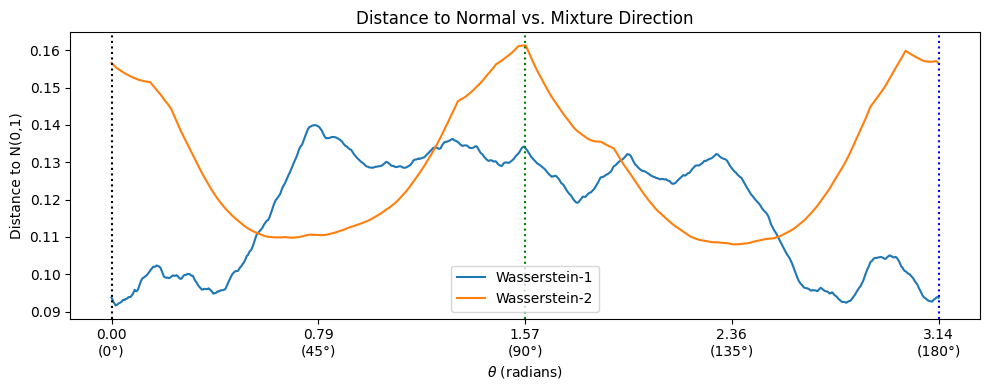

In [10]:
xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
degrees = [0, 45, 90, 135, 180]
xticklabels = [f"{val:.2f}\n({deg}°)" for val, deg in zip(xticks, degrees)]

plt.figure(figsize=(10,4))
plt.plot(thetas.cpu().numpy(), w1s, label="Wasserstein-1")
plt.plot(thetas.cpu().numpy(), w2s, label="Wasserstein-2")
plt.xlabel(r'$\theta$ (radians)')
plt.ylabel("Distance to N(0,1)")
plt.axvline(0, color='k', ls=':')
plt.axvline(np.pi/2, color='g', ls=':')
plt.axvline(np.pi, color='b', ls=':')
plt.xticks(xticks, xticklabels)
plt.legend()
plt.title("Distance to Normal vs. Mixture Direction")
plt.tight_layout()
plt.show()

## ICA: Wasserstein Distance Peaks and Interval Restriction

This plot shows the Wasserstein distances to normality for projected mixtures of continuous sources as the angle $\theta$ varies between $0$ and $\pi$. Even though $\sin$ and $\cos$ are $2\pi$-periodic, for ICA we only need $\theta \in [0, \pi]$ because projecting onto $w = [\cos\theta, \sin\theta]$ or $-w$ yields signals that are negatives of each other, and non-Gaussianity is unaffected by a sign flip.

The key peaks appear at $\theta = 0$, $\frac{\pi}{2}$, and $\pi$. At these values, the projected mixture is exactly one of the original sources (or its negative):

- At $\theta = 0$: $Y = \cos(0) S_1 + \sin(0) S_2 = S_1$
- At $\theta = \frac{\pi}{2}$: $Y = \cos\left(\frac{\pi}{2}\right) S_1 + \sin\left(\frac{\pi}{2}\right) S_2 = S_2$
- At $\theta = \pi$: $Y = \cos(\pi) S_1 + \sin(\pi) S_2 = -S_1$

These directions yield maximally non-Gaussian projections, as shown by the peaks in Wasserstein-2 distance. Other angles produce mixtures that are closer to Gaussian. Thus, searching $\theta$ in $[0,\pi]$ covers all unique ICA solutions for continuous sources.